Umbralizacion global(ISODATA)

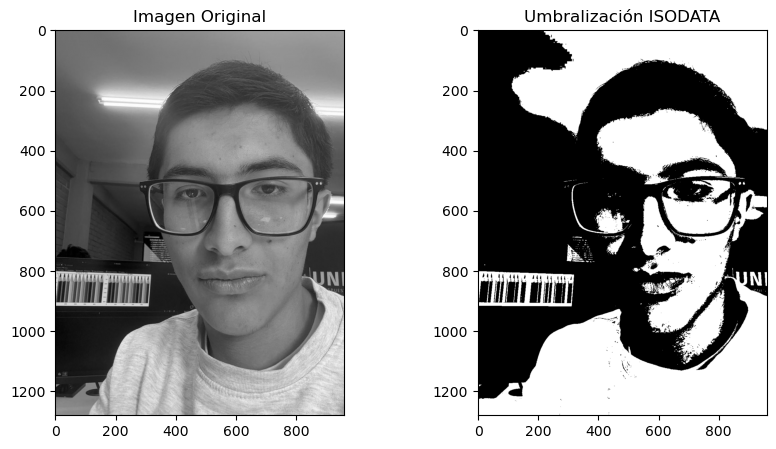

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def isodata(image):
    #umbral inicial entre 0 y 255
    umbral=128
    while True:
        grupo1=image[image<=umbral]
        grupo2=image[image>=umbral]
        #calculo de la media
        media1=np.mean(grupo1)
        media2=np.mean(grupo2)
        #calcular nuevo valor de umbral 
        nuevo_umbral=(media1+media2)/2
        #si el nuevo umbral es igual al inciial se detiene 
        if abs(nuevo_umbral-umbral)<0.5:
            break
        umbral=nuevo_umbral
        return umbral
imagen=cv2.imread("imagen1.jpg",0)
umbral_isodata=isodata(imagen)
_,umbralizacion_iso=cv2.threshold(imagen,umbral_isodata,255,cv2.THRESH_BINARY)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Imagen Original")
plt.imshow(imagen, cmap='gray')

plt.subplot(1,2,2)
plt.title("Umbralización ISODATA")
plt.imshow(umbralizacion_iso, cmap='gray')


plt.show()

Umbralizacio de 2 picos

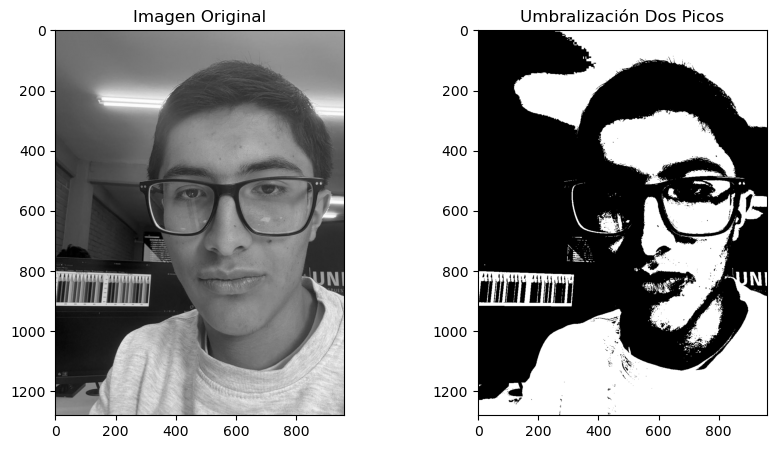

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    # Histograma
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    
    # Convertir a arreglo 1D
    pico = hist.flatten()
    
    # Derivada del histograma
    picodif = np.diff(pico)
    
    # Encontrar los dos picos principales
    primer_pico = np.argmax(picodif[:128])
    segundo_pico = np.argmax(picodif[128:]) + 128
    umbral = int((primer_pico + segundo_pico) / 2)
    
    return umbral

imagen = cv2.imread("imagen1.jpg", 0)

umbral_2_picos = dos_picos(imagen)
_, umbralizacion_2_picos = cv2.threshold(imagen, umbral_2_picos, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Imagen Original")
plt.imshow(imagen, cmap='gray')
plt.subplot(1,2,2)
plt.title("Umbralización Dos Picos")
plt.imshow(umbralizacion_2_picos, cmap='gray')
plt.show()


umbralizacion con otsu

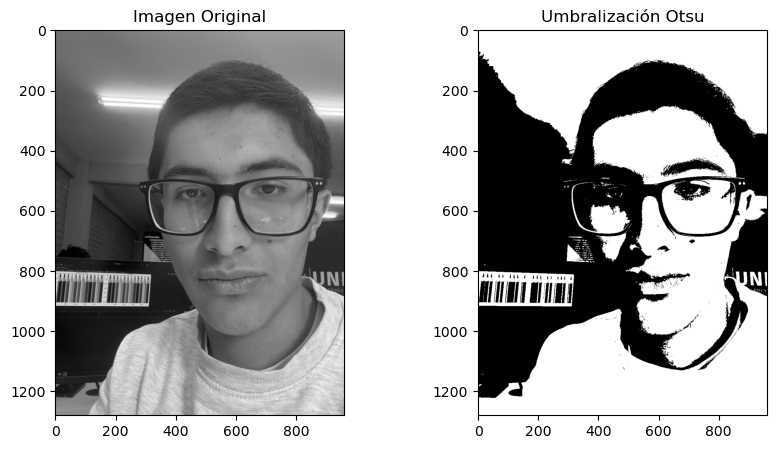

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
imagen = cv2.imread("imagen1.jpg", 0)
_,otsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
imagen_fin=np.where(imagen>otsu,255,0).astype(np.uint8)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Imagen Original")
plt.imshow(imagen, cmap='gray')


plt.subplot(1,2,2)
plt.title("Umbralización Otsu")
plt.imshow(otsu, cmap='gray')


plt.show()

Umbralizacion varibale partivcion d uina imagen

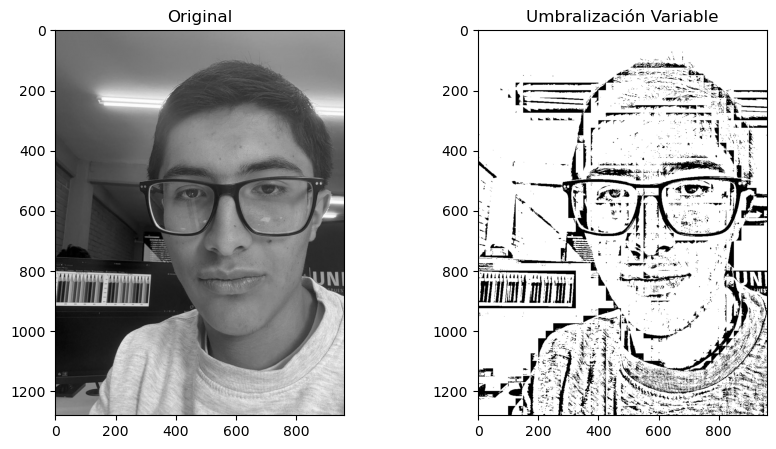

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def variable_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image)
    for y in range(0,image.shape[0],tam_bloque):
        for x in range(0,image.shape[1],tam_bloque):
            bloque=image[y:y+tam_bloque,x:x+tam_bloque]
            bloq_media=np.mean(bloque)
            umbral=bloq_media-c
            umbral_img[y:y+tam_bloque,x:x+tam_bloque]=np.where(bloque>umbral,255,0)
    return umbral_img

tam_b=25
c=10
image= cv2.imread("imagen1.jpg", 0)
img_fin=variable_part(image,tam_b,c)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(img_fin, cmap='gray')
plt.title("Umbralización Variable")

plt.show()

Propieades locales 

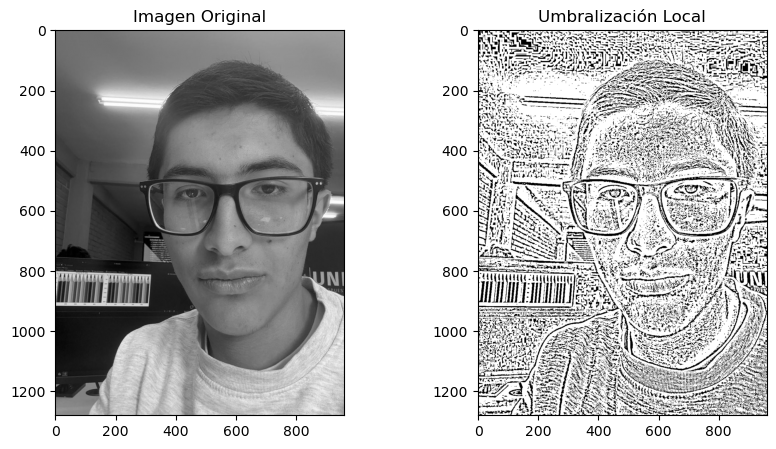

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image= cv2.imread("imagen1.jpg", 0)
def local(image,tamaño_ventana,k):
    umbral_img=np.zeros_like(image)
    pad=tamaño_ventana//2
    padded_image=cv2.copyMakeBorder(image,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana=padded_image[y:y+tamaño_ventana,x:x+tamaño_ventana]
            mean_local=np.mean(ventana)
            std_mean=np.std(ventana)
            umbral=mean_local-(k*std_mean)
            umbral_img[y,x]=255 if image[y,x]>umbral else 0
    return umbral_img

tam_ventana=15
k=0.5
img_fin=local(image,tam_ventana,k)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')


plt.subplot(1,2,2)
plt.title("Umbralización Local")
plt.imshow(img_fin, cmap='gray')


plt.show()

Umbralizacion con open cv

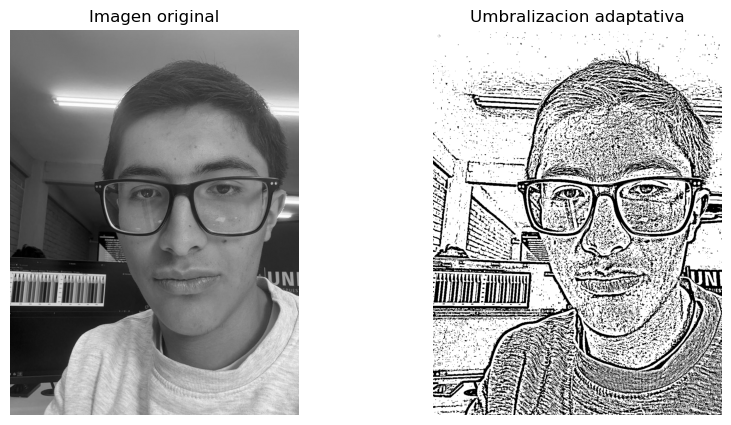

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('imagen1.jpg',0) #escala de grises

ventana=15
k=2
imagen_fin=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imagen_fin,cmap='gray')
plt.title('Umbralizacion adaptativa')
plt.axis('off')

plt.show()

otsu con formula

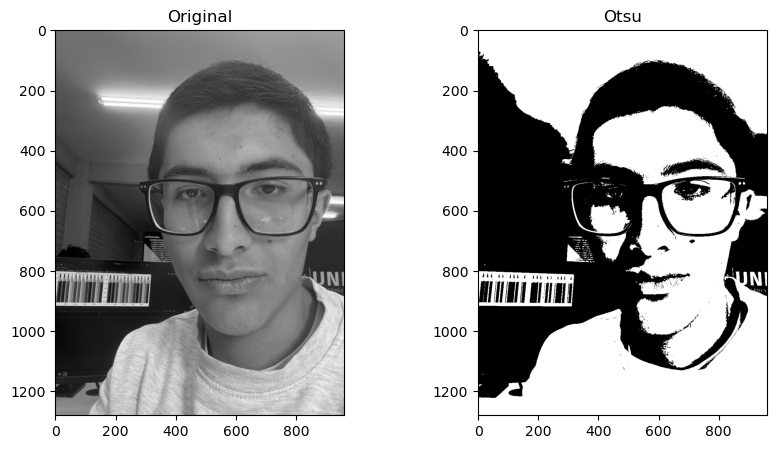

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen1.jpg', 0)

histograma = cv2.calcHist([imagen], [0], None, [256], [0,256]).ravel()
probabilidad = histograma / histograma.sum()

prob_acumulada = np.cumsum(probabilidad)
media_acumulada = np.cumsum(probabilidad * np.arange(256))
media_total = media_acumulada[-1]

varianza_entre_clases = (media_total * prob_acumulada - media_acumulada)**2 / (prob_acumulada * (1 - prob_acumulada) + 1e-10)

umbral = np.argmax(varianza_entre_clases)

_, imagen_final = cv2.threshold(imagen, umbral, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagen, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(imagen_final, cmap='gray')
plt.title("Otsu")


plt.show()